# Steve Gonzales Summer 2025 IMT 575 Lab 4: Neural Networks

In [2]:
# !pip install matplotlib scikit-learn
# !pip install pandas

All problem sets must be submitted as a Jupyter Notebook. You must organize your analysis and utilize the Notebook's markdown capabilities to present your solutions. Partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown.

## PART 1: ROSENBLATT'S ALGORITHM
    

Now we will consider how to train the perceptron so it can learn the weights automatically.

We have learned that the perceptron can only learn functions that are linearly separable: it will learn a line that separates the true values from the the false values, so if no such line exists, then the perceptron can't learn it!

To get started, we are going to generate some linearly separable data.  The code in the next cell generates such a dataset and plots it.

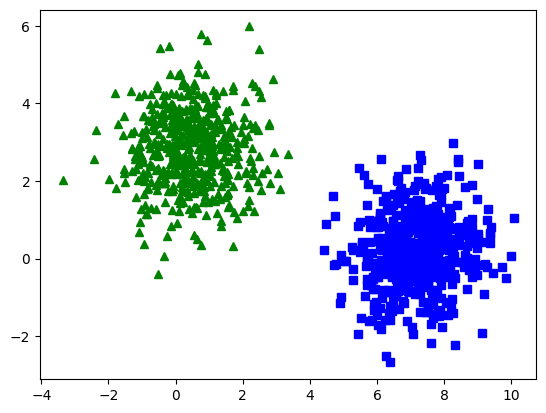

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(21)

X, y = datasets.make_blobs(n_samples=1000, centers=2, n_features=2, center_box=(0, 10))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'g^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.show()

## Question 1
🎒<font color='red'>(1 points)</font>

Show the shapes of X and y

In [4]:
print(X[:5])
print((X.shape), (y.shape))

[[ 8.9152821  -0.28182508]
 [ 6.82025164  1.20190773]
 [ 7.50784929 -0.29782537]
 [ 0.94658854  2.48370557]
 [ 7.67876963  0.36206611]]
(1000, 2) (1000,)


## Question 2 (WHY?)
🎒<font color='red'>(1 points)</font>

Add a third column of ones to the dataset X.  

Create the column using the numpy function `np.ones(shape)`

Add the column using the numpy function append.  The "axis" argument tells the function which dimension to append to: are you adding a new block of data (axis=None), a new row (axis=0; will result in an error), or a new column (axis=1)?

(We could do all this with Dataframes too, but it works out to be simpler to just use raw arrays.)

In [5]:
X_new = np.append(X, np.ones((X.shape[0], 1)), axis=1)
print(X_new.shape)
print(X_new[:5])  # Show the first 5 rows

(1000, 3)
[[ 8.9152821  -0.28182508  1.        ]
 [ 6.82025164  1.20190773  1.        ]
 [ 7.50784929 -0.29782537  1.        ]
 [ 0.94658854  2.48370557  1.        ]
 [ 7.67876963  0.36206611  1.        ]]


## Question 3
🎒<font color='red'>(1 points)</font>

Initialize a vector of weights that are between 0 and 1. 

Also select a step size

Each row of the dataset X has three values: X1, X2, and bias.  

So we will need three weights.

Remember the perceptron will be computing the expression

    w1*X1 + w2*X2 + w3*bias

This expression corresponds to a line, which we can rewrite in slope-intercept form:

    X2 = w1/w2 * X1 + w3/w2

Set the initial weights, and plot your resulting line.

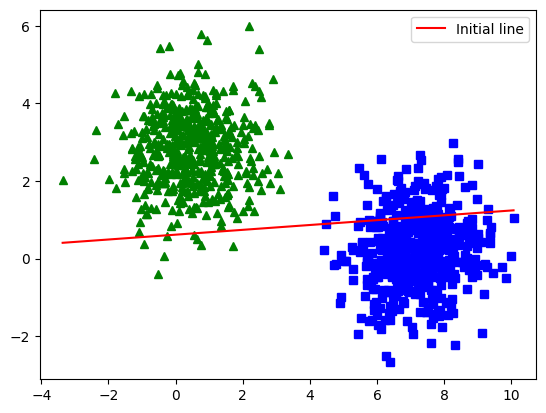

In [6]:
# Initialize a vector with 3 weights between 0 and 1
weights = np.random.rand(3)
step_size = 0.1

# Plot the green and purple blobs
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'g^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')

# Plot the line: X2 = (w1/w2) * X1 + (w3/w2)
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = (weights[0] / weights[1]) * x_vals + (weights[2] / weights[1])
plt.plot(x_vals, y_vals, 'r-', label='Initial line')

plt.legend()
plt.show()

Your line probably does not separate the two blobs.  That's fine -- we're going to automatically adjust the weights  until it does separate them!  That's what Rosenblatt's algorithm does.

## Question 4
🎒<font color='red'>(8 points)</font>

You will now implement the myPerceptron function to implement your own learning procedure.  Pseudocode for the function body appears in the next cell.  


Some notes:

a) Create a function called myPerceptron that takes in the following four inputs: $X$, $Y$, a vector of weights, and your step size.

b) The function should pass through a single iteration of Rosenblatt's algorithm&mdash;we will run this function until convergence in the next question. 

This means we will handle the whole dataset, but only one time. We will make multiple passes over the dataset in the next question.

But in this question, you are implementing the myPerceptron function, not this outer loop.

c) The function should output two things every time it is called: the vector of updated weights and a count of the number of misclassifications. A function that returns two things looks like this:

    def somefunc(x):
        return x+1, x-1
    a, b = somefunc(x)

d) Implement the body of the function

Look at the [bottom of 4.9 for pseudocode for Rosenblatt's algorithm](https://canvas.uw.edu/courses/1576691/pages/4-dot-9-back-to-basics-nn-for-logistic-regression?module_item_id=15264372).
Rosenblatt’s algorithm (only for one-layer networks) works like this:
1. Initialize weights to random values.
2. While stopping criterion not met:
3. For each training example (1 to m):
4. Compute the outputs: ŷ = wX ≥ 0
5. Calculate change in weight: Δw = η(y – ŷ)X
6. η is the step size
7. Update weight: w = w + Δw

[This article](https://sebastianraschka.com/Articles/2015_singlelayer_neurons.html) provides much more detail, but be careful not to just copy and paste code; it will be difficult to retrofit to this assignment.

e) Note: Use a dot product operation to multiply the weight vector with the input matrix in calculations.  Make sure you understand what this means!

The inputs to a neuron are all added together: w1x1+ w2x2 + ... wnxn

That's the same operation as the dot product of a vector (w1, w2, ..., wn) and a vector (x1, x2, ..., xn)

If needed, review the [math fundamentals in 4.4](https://canvas.uw.edu/courses/1576691/pages/4-dot-4-math-fundamentals-review?module_item_id=15264367)

f) Note: keep in mind that $\hat{y}$ is a "raw" prediction and must be thresholded to 0 or 1 to be compared with the target value $y$.


<div class="alert alert-block alert-info">
errors = 0 
    
For each training example i from 1 to m:  
  &nbsp;&nbsp;&nbsp;&nbsp; let x = X[i], y = Y[i]  
  &nbsp;&nbsp;&nbsp;&nbsp; *# We're only working with the ith record*  
  
  
  &nbsp;&nbsp;&nbsp;&nbsp; $\hat{y} = (wx >= 0)$    
  &nbsp;&nbsp;&nbsp;&nbsp; *# Compute the predicted values for $y$*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# wx is the dot product of the weights w and the vector x, where x is the ith record in the dataset X*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# (wx >= 0) means every value greater than or equal to 0 becomes 1 and every value less 0 becomes 0*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# this is the "thresholding" step*  
  
  &nbsp;&nbsp;&nbsp;&nbsp; $\Delta w = \eta (y - \hat{y})x$  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Calculate change in weight:*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# $\eta$ is the step size*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# $y$ is the true value (target) and $\hat{y}$ is the prediction we just computed above.*   
  &nbsp;&nbsp;&nbsp;&nbsp; *# Take their difference, multiply by step size, and multiply that by the vector x*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Check: What is the shape of $\Delta w$?*  
        
  &nbsp;&nbsp;&nbsp;&nbsp; w = w + $\Delta w$  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Update weights*  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Now adjust the weights: the new weights = the old weights + the changes to the weights*  
 
  &nbsp;&nbsp;&nbsp;&nbsp; if $y \neq \hat{y}$ then $\text{errors} = \text{errors} + 1$  
  &nbsp;&nbsp;&nbsp;&nbsp; *# Compute the error: If the prediction was wrong for this record, then add one to the count of errors*  
  
return w, errors  
*# Now we're done and we can return the adjusted weights and the accumulated errors*  
 </div>

In [7]:
# Weights we created above in Question 3; randomly initialized
def myPerceptron(X, y, weights, step_size):
    errors = 0
    for i in range(X.shape[0]):
        x_i = X[i]
        y_i = y[i]
        np_dot_prod = np.dot(weights, x_i)
        y_hat_np = 1 if np_dot_prod >= 0 else 0
        # Manually compute the dot product of weights and x_i
        dot_prod = 0
        for j in range(len(weights)):
            dot_prod += float(weights[j]) * float(x_i[j])
        y_hat_man = 1 if dot_prod >= 0 else 0
        # Check that the two methods of computing y_hat are the same
        # print(x_i, np_dot_prod, dot_prod)
        assert y_hat_np == y_hat_man
        delta_w = step_size * (y_i - y_hat_man) * x_i
        weights = weights + delta_w
        if y_i != y_hat_man:
            errors += 1
    return weights, errors
print(weights)
step_size = 0.1  # AKA Learning Rate
# print(myPerceptron(X_new, y, weights, step_size))

[0.05020139 0.8052792  0.49808852]


## Question 5
🎒<font color='red'>(4 points)</font>

Run your myPerceptron function using your starting weights and step size until convergence. 

One possible structure for this is to wrap it in a while loop:

    (Initialize weights here)
    while errors:
        weights, errors = myPerceptron(X, y, weights, step)

Once finished, plot the number of errors for each iteration vs. the iteration number. (You'll need to keep track of the errors at each step so you can plot them.)

How many iterations did the function take to converge? What does the shape of the plot of the errors look like? Do you think gradient descent would generate a plot of errors vs. iteration (epoch) that looks similar? Why or why not?

In [8]:
def plot_perceptron(X, y, weights=None, step_size=.1, print_weights=True, max_iterations=2500):
    iteration, errors = 0, 1  # Initialize errors to a non-zero value to enter the loop
    errors_list = []
    while errors and iteration <= 2500:
        weights, errors = myPerceptron(X_new, y, weights, step_size)
        errors_list.append(errors)
        iteration += 1
        if print_weights:
            print("Iteration: ", iteration, "Weights", weights, "Errors: ", errors)

    print(f'Converged in {iteration} iterations, with weights: {weights}')

    plt.figure(figsize=(20, 4))  # Very wide, not tall
    plt.plot(range(1, iteration + 1), errors_list, marker='o', markersize=2, linewidth=0.5)
    plt.xlabel('Iteration')
    plt.ylabel('Number of errors')
    plt.title('Errors vs. Iteration (Perceptron Training)')
    plt.tight_layout()
    plt.show()
    return weights
weights_end = {}

Iteration:  1 Weights [ 0.73344883 -1.28174896 -0.40191148] Errors:  17
Iteration:  2 Weights [ 0.81784636 -1.31441014 -0.60191148] Errors:  4
Iteration:  3 Weights [ 1.05798815 -1.21342835 -0.70191148] Errors:  3
Iteration:  4 Weights [ 1.0641244  -1.23486643 -0.90191148] Errors:  4
Iteration:  5 Weights [ 0.83011887 -1.3572863  -1.00191148] Errors:  1
Iteration:  6 Weights [ 0.83011887 -1.3572863  -1.00191148] Errors:  0
Converged in 6 iterations, with weights: [ 0.83011887 -1.3572863  -1.00191148]


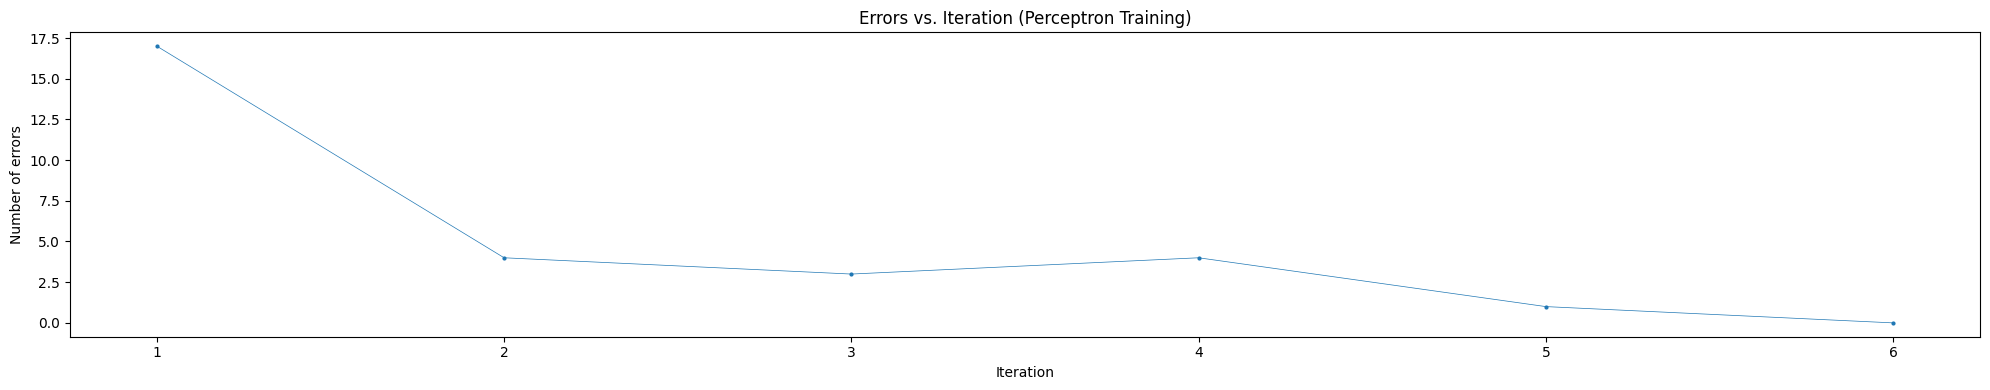

In [9]:
# Initialize weights from Q4
weights_start = [0.05020139, 0.8052792, 0.49808852]
weights_end['step.1'] = plot_perceptron(X_new, y, weights_start, step_size=.1)

<b>Answer:</b><p>
  - It took six iterations to converge.
  - The plot of errors vs. iteration shows a decreasing trend, which is expected as the perceptron learns to classify the data correctly.
  - The shape of the plot resembles a typical gradient descent error plot, where the error decreases over time as the model learns. However, unlike gradient descent, which may oscillate or plateau, the perceptron converges more directly due to its binary classification nature.
  - Iteration 4 went up likely due to the perceptron adjusting weights in a way that temporarily misclassified some points, but it corrected itself in the next iteration.

Iteration:  1 Weights [ 0.11484867 -0.21438405  0.06808852] Errors:  57
Iteration:  2 Weights [ 0.11268248 -0.22113276  0.01808852] Errors:  7
Iteration:  3 Weights [ 0.1338378  -0.2226727  -0.02191148] Errors:  6
Iteration:  4 Weights [ 0.13445143 -0.22481651 -0.04191148] Errors:  4
Iteration:  5 Weights [ 0.11743778 -0.22799178 -0.05191148] Errors:  1
Iteration:  6 Weights [ 0.14145196 -0.2178936  -0.06191148] Errors:  3
Iteration:  7 Weights [ 0.1437885  -0.21827403 -0.08191148] Errors:  4
Iteration:  8 Weights [ 0.12677486 -0.22144929 -0.09191148] Errors:  1
Iteration:  9 Weights [ 0.15078903 -0.21135112 -0.10191148] Errors:  3
Iteration:  10 Weights [ 0.13377539 -0.21452638 -0.11191148] Errors:  1
Iteration:  11 Weights [ 0.11676174 -0.21770165 -0.12191148] Errors:  1
Iteration:  12 Weights [ 0.16081476 -0.19529864 -0.12191148] Errors:  2
Iteration:  13 Weights [ 0.12040056 -0.21071589 -0.14191148] Errors:  2
Iteration:  14 Weights [ 0.12040056 -0.21071589 -0.14191148] Errors:  0


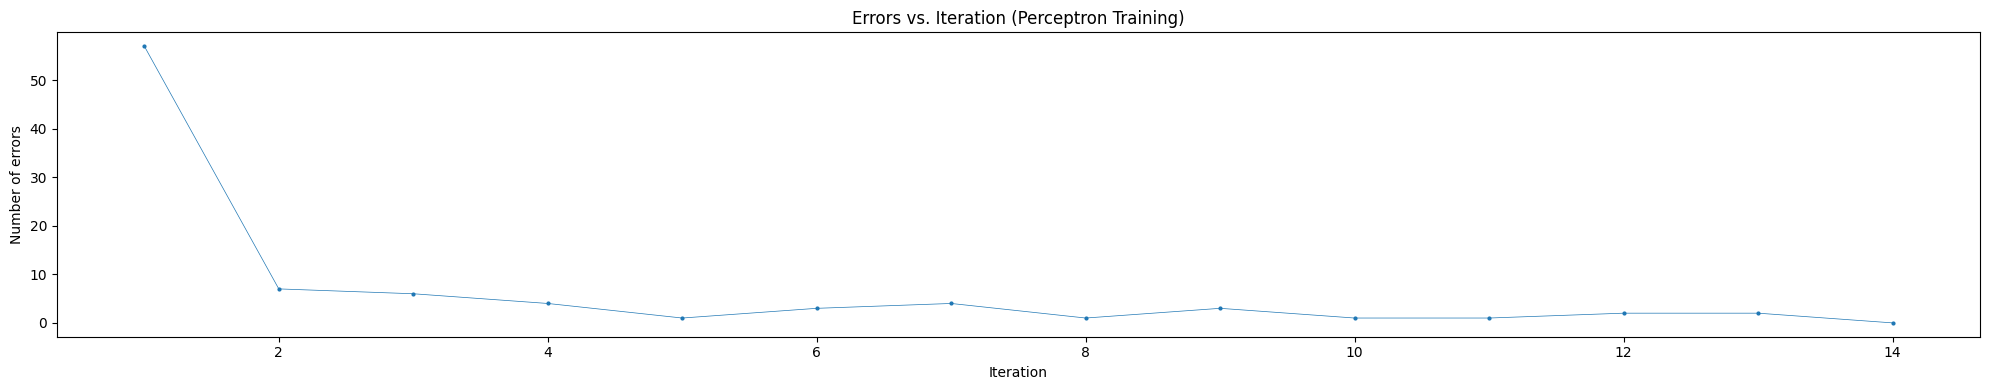

In [10]:
weights_end['step.01'] = plot_perceptron(X_new, y, weights, step_size=0.01)  # Try a smaller step size

Iteration:  1 Weights [ 0.01555359 -0.11407409  0.17708852] Errors:  357
Iteration:  2 Weights [ 0.03224463 -0.13403073  0.14808852] Errors:  43
Iteration:  3 Weights [ 0.04254721 -0.1416944   0.13008852] Errors:  26
Iteration:  4 Weights [ 0.04251756 -0.14646896  0.11708852] Errors:  17
Iteration:  5 Weights [ 0.05011734 -0.14754908  0.10608852] Errors:  17
Iteration:  6 Weights [ 0.04918998 -0.15101272  0.09508852] Errors:  15
Iteration:  7 Weights [ 0.05185509 -0.15224211  0.08608852] Errors:  13
Iteration:  8 Weights [ 0.05373494 -0.15288073  0.07808852] Errors:  12
Iteration:  9 Weights [ 0.0556148  -0.15351934  0.07008852] Errors:  12
Iteration:  10 Weights [ 0.0588535  -0.15319599  0.06308852] Errors:  11
Iteration:  11 Weights [ 0.05662251 -0.15521336  0.05508852] Errors:  10
Iteration:  12 Weights [ 0.0591254  -0.15434786  0.05008852] Errors:  7
Iteration:  13 Weights [ 0.06162828 -0.15348237  0.04508852] Errors:  7
Iteration:  14 Weights [ 0.05938943 -0.15432721  0.04008852] 

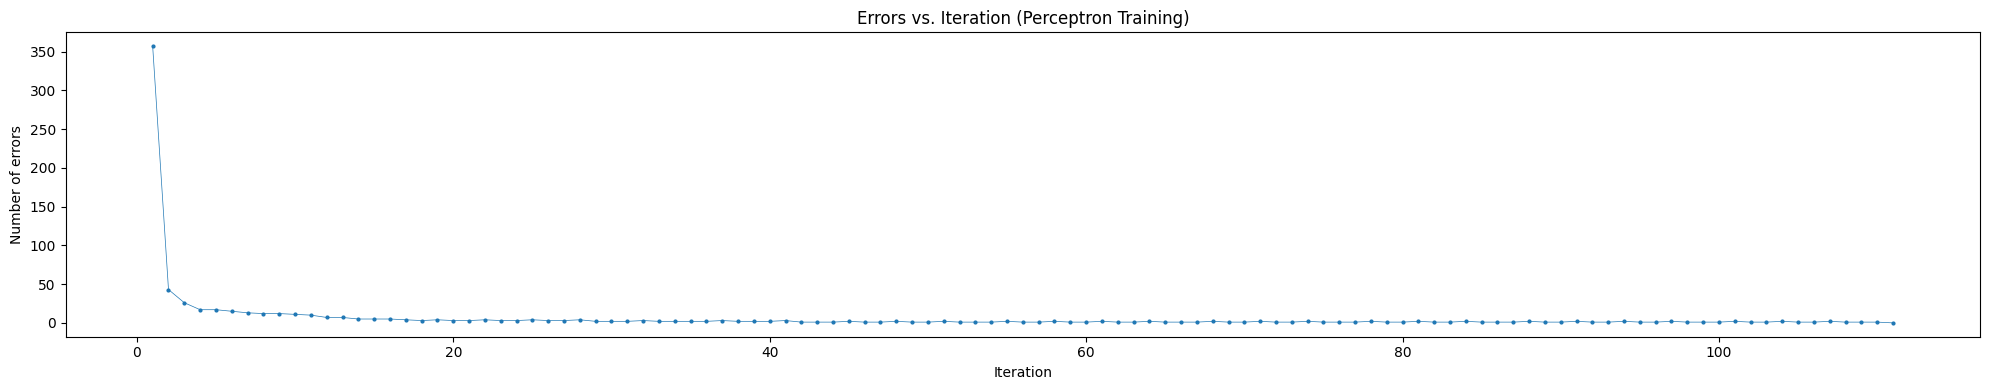

In [11]:
weights_end['step.001'] = plot_perceptron(X_new, y, weights, step_size=0.001)  # Try a smaller step size

Iteration:  1 Weights [ 8.14462747 -8.22545627 -3.50191148] Errors:  10
Iteration:  2 Weights [  7.10426982 -10.29706343  -6.50191148] Errors:  5
Iteration:  3 Weights [  7.94824512 -10.62367522  -8.50191148] Errors:  4
Iteration:  4 Weights [11.71656755 -8.60049609 -8.50191148] Errors:  2
Iteration:  5 Weights [  7.64116176 -11.0388034  -10.50191148] Errors:  2
Iteration:  6 Weights [  7.64116176 -11.0388034  -10.50191148] Errors:  0
Converged in 6 iterations, with weights: [  7.64116176 -11.0388034  -10.50191148]


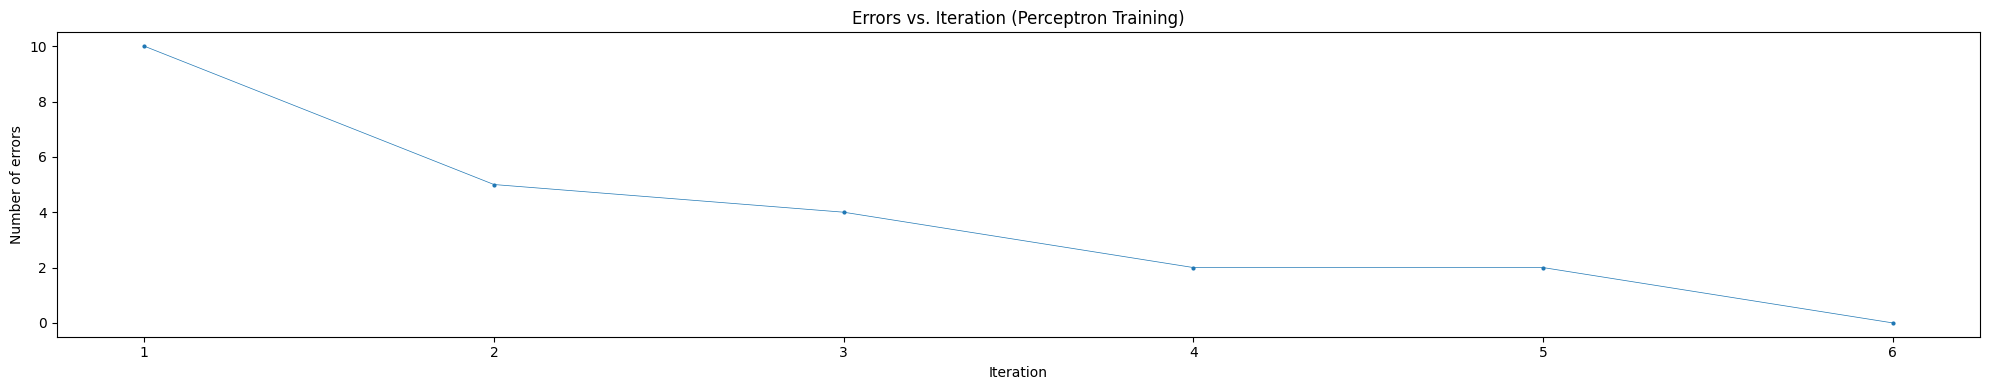

In [12]:
weights_end['step1'] = plot_perceptron(X_new, y, weights, step_size=1)  # Try a smaller step size

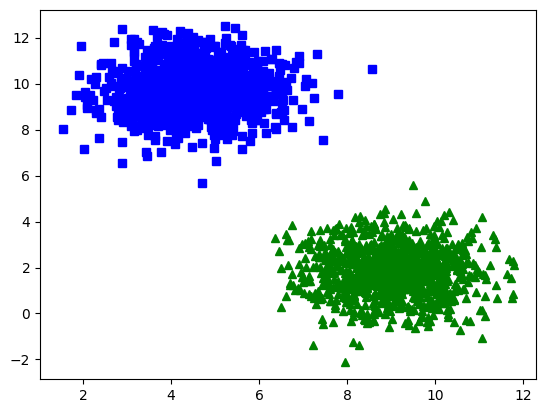

(2000, 3)
[[5.12864737 8.70679223 1.        ]
 [9.02501795 3.287886   1.        ]
 [8.180754   2.60749825 1.        ]
 [8.76152117 0.44963444 1.        ]
 [3.05655074 8.75045979 1.        ]]
Converged in 2501 iterations, with weights: [ 4.98616478 -1.10793104  2.06411513]


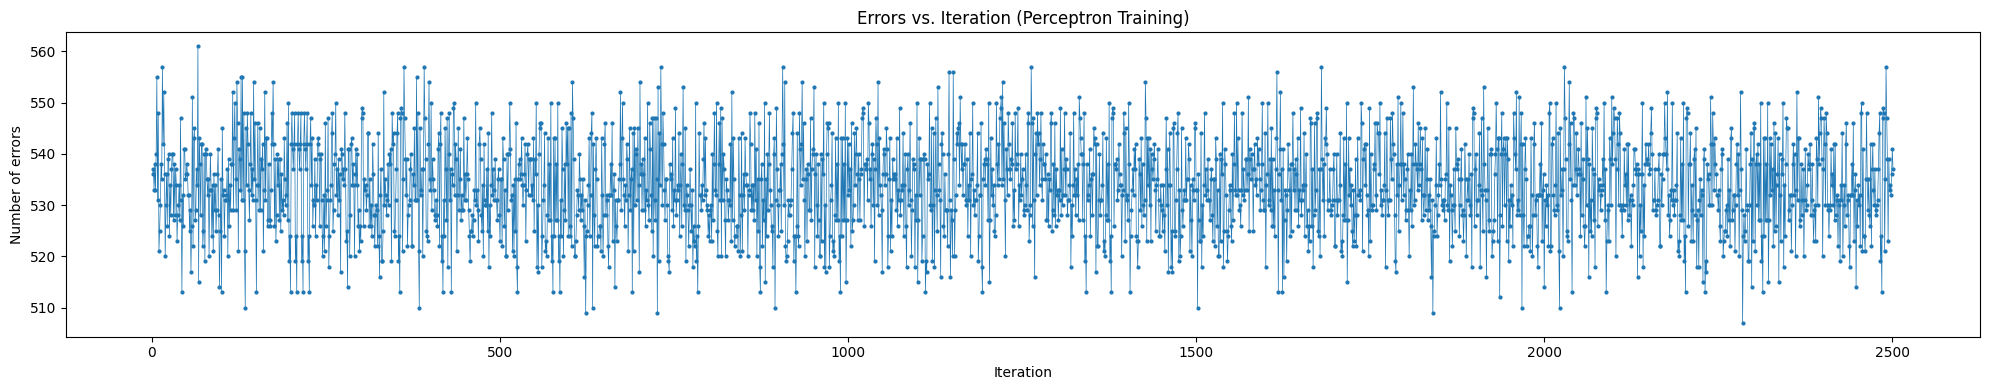

array([ 4.98616478, -1.10793104,  2.06411513])

In [13]:
# Trying a larger data set
X_lg, y_lg = datasets.make_blobs(n_samples=2000, centers=2, n_features=2, center_box=(0, 10))
plt.plot(X_lg[:, 0][y_lg == 0], X_lg[:, 1][y_lg == 0], 'g^')
plt.plot(X_lg[:, 0][y_lg == 1], X_lg[:, 1][y_lg == 1], 'bs')
plt.show()
weights_lg = np.random.rand(3)
X_lg = np.append(X_lg, np.ones((X_lg.shape[0], 1)), axis=1)
print(X_lg.shape)
print(X_lg[:5])
plot_perceptron(X_lg, y_lg, weights_lg, step_size=1, print_weights=False)  # Try a smaller step size

Tried 2,000 and 10,000 samples: the errors are all over the place.  The perceptron never converged.

## Question 6
🎒<font color='red'>(1 points)</font>

The values of your weights after convergence can be used to draw a separation line where:

$$
w_{1} x_{1}+w_{2} x_{2}+w_{3} x_{3}=0 \\
$$

Consider your plot from Q1. We want to superimpose the separation line that we calculated onto the plot. Solve the equation above for whichever variable is on the y-axis of the plot from Q1, be it $X_1$ or $X_2$.


In other words, solve the equation above such that you have something of the form `y = mx + b`, where $y$ is the variable on the y-axis of the plot from Q1 and $x$ is the variable on the x-axis. 

<div class="alert alert-block alert-info">
Remember that $X_{0}$ is our bias term of 1 and $w_{0} X_{0}$ is therefore a constant. 
</div>

Plot this line onto a copy of your plot from Q1 and comment on what you see.

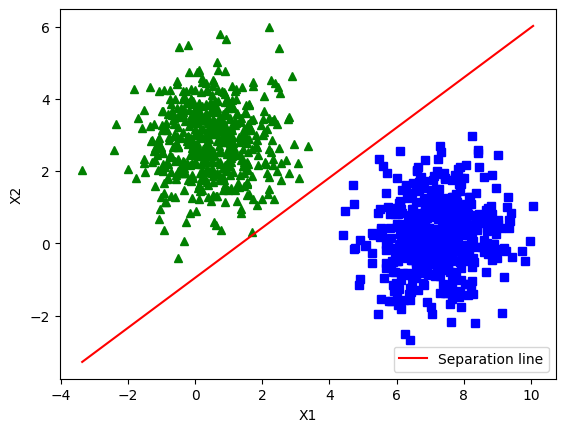

In [14]:
# Plot the green and purple blobs
weights = weights_end['step1']
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'g^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
# Plot the line: X2 = (w1/w2) * X1 + (w3/w2)
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = -(weights[0] / weights[1]) * x_vals - (weights[2] / weights[1])
plt.plot(x_vals, y_vals, 'r-', label='Separation line')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

To solve for the separation line, start from the equation:

$w_1 x_1 + w_2 x_2 + w_3 \cdot 1 = 0$

Assuming ( x_2 ) is on the y-axis and ( x_1 ) is on the x-axis, solve for ( x_2 ):

$w_2 x_2 = -w_1 x_1 - w_3$<p>
$x_2 = -\frac{w_1}{w_2} x_1 - \frac{w_3}{w_2}$

This is in the form $y = mx + b$

## PART 2: OUT-OF-THE-BOX NEURAL NETWORKS 

In part 3, we will build a multi-layer network.  As we've seen, a single layer network can learn linearly separable datasets, and we saw in the online material that they can *only* learn linearly separable data.  But we need complex, curvy boundaries to separate the classes -- real data is complex and has many dimensions.   

But now we won't bother implementing the network and learning process by hand. We will use the libraries provided for us. 

You now know how the training process works for a simple network: Calculate an adjustment to the weights based on the difference between the true value and the predicted value, apply the adjustment, and repeat until there are no more errors.  In general, this process involves computing the *derivative* of the objective function: find the direction to adjust the weights that lead the biggest decrease in error.   We roll the ball downhill to find a point where the error is minimized.  Another difference: The "error" will not necessarily converge; you can't always get rid of all errors.  So "convergence" will be something the algorithm will estimate.  It might be that if you trained a little longer, the error might go down, or it might not.  You eventually just have to say that the current model is "good enough."   

## Question 7
🎒<font color='red'>(1 points)</font>

Import the [california housing dataset](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html) from sklearn.


In [15]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Question 8
🎒<font color='red'>(1 points)</font>

Plot the data to see what we're working with.

x-axis: Latitude

y-axis: Longitude

color: medianvalue

The result should be roughly in the shape of the state of California.

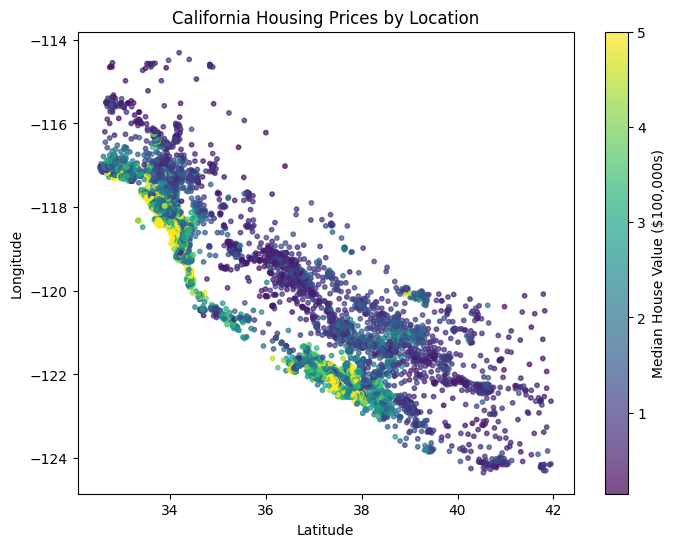

In [16]:
# Convert the data set to a DataFrame
df = california_housing.frame  # DataFrame from the loaded dataset
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['Latitude'], df['Longitude'],
    c=df['MedHouseVal'], cmap='viridis', s=10, alpha=0.7
)
plt.colorbar(scatter, label='Median House Value ($100,000s)')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('California Housing Prices by Location')
plt.show()

## Question 9
🎒<font color='red'>(1 points)</font>

Create a new binary variable `highpriced` that indicates whether the house is greater than \$200,000

The target `MedHouseVal` gives the price in hundreds of thousands of dollars, so you want values of `MedHouseVal` > 2

In [17]:
df['highpriced'] = (df['MedHouseVal'] > 2.00).astype(int)
display(df)
print(len(df))

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,highpriced
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0


20640


## Question 10
🎒<font color='red'>(1 points)</font>

Create a training/test split for the california dataset.  Use sklearn [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  Pass `california.data` as the X values and your new `highpriced` variable as the y values.

Use the `test_size` parameter to control how big the test set will be; assume 0.2.

You can also use the `random_state` parameter to make sure you get the same results every time.

show the shape of the result X_test and y_test.  They should be (4128, 8) and (4128,) respectively.

In [18]:
from sklearn.model_selection import train_test_split

X_house = california_housing.data
y_house = df['highpriced']

X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

print(X_test.shape)  # Should be (4128, 8)
print(y_test.shape)  # Should be (4128,)

(4128, 8)
(4128,)


In [19]:
print(california_housing.frame.columns)
print(df.columns)
display(california_housing.frame)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'highpriced'],
      dtype='object')
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'highpriced'],
      dtype='object')


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,highpriced
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1
...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0


In [20]:
# Now will rebuild the data frame with all features scaled
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
# Select only numeric columns for scaling
cols_to_scale = [x for x in df.columns if x not in ['highpriced', 'MedHouseVal']]
scaled_values = scaler.fit_transform(df[cols_to_scale])

# Create a new DataFrame with scaled values and the same column names
df_scaled = pd.DataFrame(scaled_values, columns=cols_to_scale, index=df[cols_to_scale].index)

# Do NOT add back in MedHouseVal or High Price
# non_scaleed_cols = df.drop(columns=cols_to_scale)
# df_scaled = pd.concat([df_scaled, non_scaleed_cols], axis=1)

display(df_scaled.head())

X_house = df_scaled
y_house = df['highpriced']

X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


## Question 11
🎒<font color='red'>(3 points)</font>

Now use [`sklearn.MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) to train a model.

MLP stands for multilayer perceptron.   Classifier means we will be predicting whether each house is high priced or not.

Use the parameter `hidden_layer_sizes` to control both how many layers your model will have and how many neurons per layer.

The  parameter `hidden_layer_sizes` takes a tuple of integers.  For example,  `hidden_layer_sizes=(4,6)` means a two layer model with 4 neurons in the first layer and 6 neurons in the second layer.

Also set `max_iter=1000` just in case your model doesn't converge; we don't want it to train forever.

Report the accuracy on both training and test by calling the score method of the trained model.

    print('Training accuracy for architecture (4,6): {:.3f}'.format(mlp.score(X_train, y_train)))
    print('Testing accuracy for architecture (4,6): {:.3f}'.format(mlp.score(X_test, y_test)))


In [21]:
from sklearn.neural_network import MLPClassifier
np.seterr(divide='ignore', invalid='ignore', over='ignore')
# Create the MLPClassifier with a specific architecture and max_iter=1000
mlp = MLPClassifier(hidden_layer_sizes=(4, 6), max_iter=1000, random_state=42)
# Fit the model to the training data
mlp.fit(X_train, y_train)

# Report accuracy
print('Training accuracy for architecture (4,6): {:.3f}'.format(mlp.score(X_train, y_train)))
print('Testing accuracy for architecture (4,6): {:.3f}'.format(mlp.score(X_test, y_test)))

Training accuracy for architecture (4,6): 0.860
Testing accuracy for architecture (4,6): 0.863


Running the above data on the non scaled features yields accuracy of about 50%.

## Question 12
🎒<font color='red'>(2 points)</font>

Train several models for different architectures: vary the number of layers and number of neurons and see how high you can get.  Show the accuracy for all the models you tried.  Which is best?

In [22]:
# Trying different # of levels and neurons
for l in range(2, 10):
    for n in range(2, 7):
        arch = tuple([n] * l)
        mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
        mlp.fit(X_train, y_train)
        print(f'Architecture {arch}', end=' ')
        print('Accuracy: training={:.3f}'.format(mlp.score(X_train, y_train)), end=', ')
        print('testing={:.3f}'.format(mlp.score(X_test, y_test)))

Architecture (2, 2) Accuracy: training=0.576, testing=0.586
Architecture (3, 3) Accuracy: training=0.854, testing=0.853
Architecture (4, 4) Accuracy: training=0.867, testing=0.876
Architecture (5, 5) Accuracy: training=0.855, testing=0.862
Architecture (6, 6) Accuracy: training=0.864, testing=0.871
Architecture (2, 2, 2) Accuracy: training=0.576, testing=0.586
Architecture (3, 3, 3) Accuracy: training=0.859, testing=0.857
Architecture (4, 4, 4) Accuracy: training=0.860, testing=0.866
Architecture (5, 5, 5) Accuracy: training=0.870, testing=0.871
Architecture (6, 6, 6) Accuracy: training=0.862, testing=0.861
Architecture (2, 2, 2, 2) Accuracy: training=0.576, testing=0.586
Architecture (3, 3, 3, 3) Accuracy: training=0.863, testing=0.863
Architecture (4, 4, 4, 4) Accuracy: training=0.854, testing=0.854
Architecture (5, 5, 5, 5) Accuracy: training=0.865, testing=0.868
Architecture (6, 6, 6, 6) Accuracy: training=0.872, testing=0.868
Architecture (2, 2, 2, 2, 2) Accuracy: training=0.576, 

From the results, having 2 neurons is not enough; almost all the accuracies are below 0.5.<p>
The best architecture was (4, 4) with an accuracy of 0.867 on the training set and 0.876 on the test set.<p>

In [23]:
arch = tuple([64, 32])
mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
print(f'Architecture {arch}', end=' ')
print('Accuracy: training={:.3f}'.format(mlp.score(X_train, y_train)), end=', ')
print('testing={:.3f}'.format(mlp.score(X_test, y_test)))

Architecture (64, 32) Accuracy: training=0.902, testing=0.876


Trying some two level architectures, I figured out that by creating two very deep layers, we get the best accuracy of .902 and .876

## Question 13
🎒<font color='red'>(1 points)</font>

Show a plot of where your model tends to make mistakes for your best model.  Plot latitude and longitude, but color the points by whether the prediction matches the ground truth.  

Comment on what you see -- are they geographical patterns to the errors?

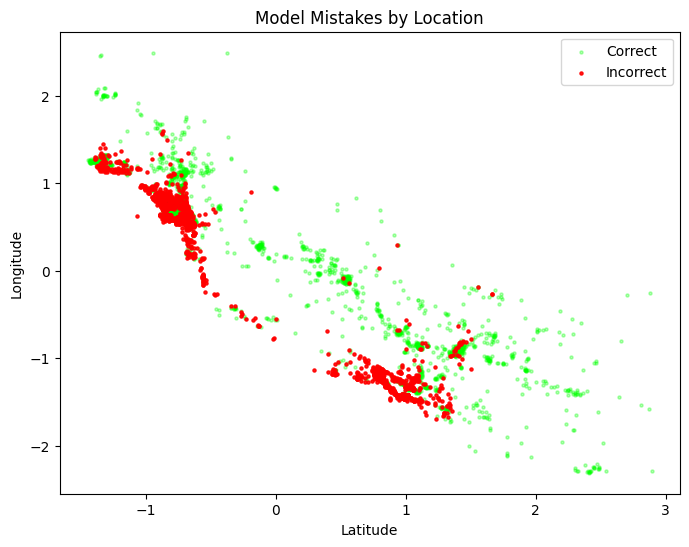

In [24]:
arch = (2, 2)  # Best architecture found in the previous question
mlp = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
# Get predictions for the test set
y_pred = mlp.predict(X_test)
# Create a boolean mask for correct/incorrect predictions
correct = (y_pred == y_test.values)

# Plot: green for correct, red for incorrect
plt.figure(figsize=(8, 6))
plt.scatter(
    X_test['Latitude'][correct], X_test['Longitude'][correct],
    c='lime', s=5, alpha=0.3, label='Correct'
)
plt.scatter(
    X_test['Latitude'][~correct], X_test['Longitude'][~correct],
    c='red', s=5, alpha=0.9, label='Incorrect'
)
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Model Mistakes by Location')
plt.legend()
plt.show()

At first glance it seems like there are more incorrect predictions along the coast, but likely this is just because there are more houses along the coast. Also, it is hard to tell if there are more incorrect predictions in the North vs the South.<p>
The best way to measure would be to compare the % wrong by region, but that would require more work to define the regions.<p>

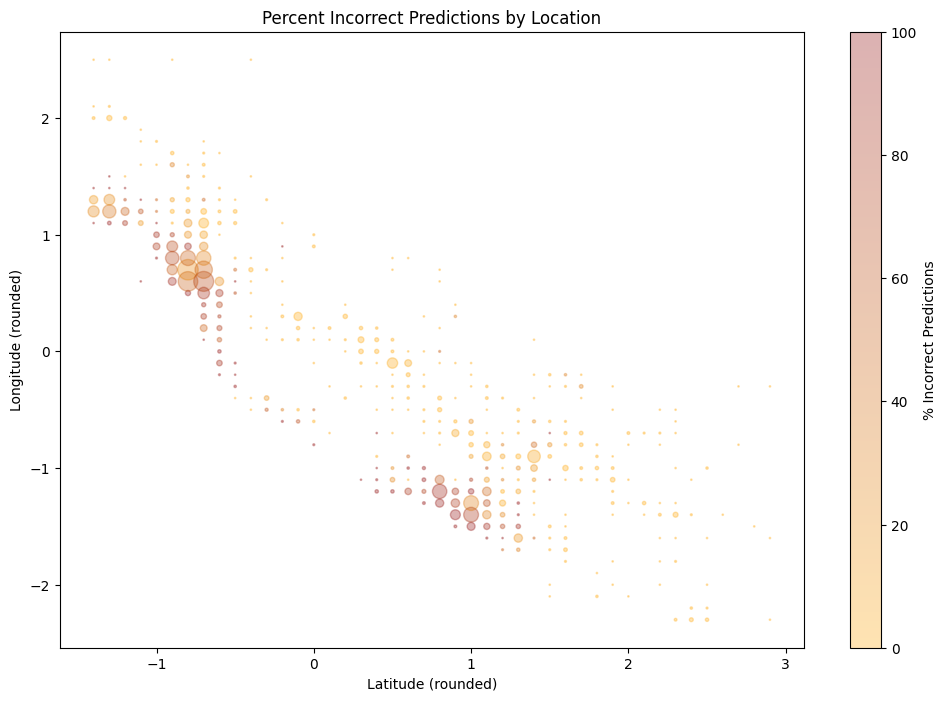

In [25]:
from matplotlib.colors import LinearSegmentedColormap

# DataFrame with test set coordinates and prediction correctness
results = pd.DataFrame({
    'Latitude': X_test['Latitude'],
    'Longitude': X_test['Longitude'],
    'correct': (y_pred == y_test.values)
})

# Aggregate by rounded coordinates
results['lat_agg'] = results['Latitude'].round(1)
results['lon_agg'] = results['Longitude'].round(1)

# Count total and incorrect predictions per location
agg = results.groupby(['lat_agg', 'lon_agg']).agg(
    total_count=('correct', 'size'),
    incorrect_count=('correct', lambda x: (~x).sum())
).reset_index()

# Calculate percent incorrect
agg['percent_incorrect'] = 100 * agg['incorrect_count'] / agg['total_count']

# Plot: circle size = total homes, color = percent incorrect
plt.figure(figsize=(12, 8))
# Custom colormap: green (0%) to dark red (100%)
cmap = LinearSegmentedColormap.from_list('custom', ['orange', 'darkred'])

scatter = plt.scatter(
    agg['lat_agg'], agg['lon_agg'], s=agg['total_count'],
    c=agg['percent_incorrect'], cmap=cmap, alpha=0.3, vmin=0, vmax=100)
plt.colorbar(scatter, label='% Incorrect Predictions')
plt.xlabel('Latitude (rounded)')
plt.ylabel('Longitude (rounded)')
plt.title('Percent Incorrect Predictions by Location')
plt.show()

Creating a scatter plot of the incorrect only predictions looks like Northern California (Bay Area) has a lot of incorrect predictions. Southern California does have some incorrect areas but the circles are much smaller.

## Question 14: Reflection
🎒<font color='red'>(4 points)</font>

In Part 1, we studied how a simple neural network computes its results, and configured results by hand.

In Part 2, we trained the model automatically by writing a training procedure by hand.

In Part 3, we used a library to set up the model and train it with just a few lines of code.

Reflect on your results overall by considering the following questions:

* Part 1: Do you feel you understand how neural networks compute the answer?  Why were these single-layer networks studied originally?  What was their main limitation?

* Part 2: Do you feel you understand how training works?  How does the model learn to get better results?

* Part 3: What kinds of architectures worked well in Part 3?  Why do you think that is?  What are some ways we might improve results?  What additional data might we want to collect to make the model better?



# Answers
<b>Part 1: Do you feel you understand how neural networks compute the answer? Why were these single-layer networks studied originally? What was their main limitation?</b><p>
Yes, I understand how a Neural Network computes the answer. It does this by taking a weighted sum of the inputs, applying an activation function, and producing an output. The weights are adjusted during training to minimize the error between the predicted and actual outputs.<p>
Single-layer networks were studied originally because they are simple and can model linear relationships.<p>
The main limitation of single-layer networks is that they can only learn linearly separable functions, meaning they cannot capture complex relationships in the data. This is why multi-layer networks (deep learning) were developed, as they can learn hierarchical representations and model non-linear relationships.<p>
All the models in the first part over fit and converged quickly without error.

<b>Part 2: Do you feel you understand how training works?  How does the model learn to get better results?</b><p>
Yes, I understand how training works. The model gets better results by adjusting the weights based on the difference between the predicted output and the actual output. It is accomplished via backpropagation, where the error is propagated backward through the network to update the weights using gradient descent or similar optimization algorithms.<p>
Training and Learning are distinct concepts. Training is the process of adjusting the model's parameters (weights) based on the training data, while learning refers to the model's ability to generalize from the training data to make accurate predictions on unseen data.<p>

<b>Part 3: What kinds of architectures worked well in Part 3? Why do you think that is? What are some ways we might improve results? What additional data might we want to collect to make the model better?</b><p>
The architecture that worked well in Part 3 was the one with two hidden layers, each with four neurons (4, 4). But then increasing up to (64,32) yielded the best accuracy.<p>
This architecture was able to capture the complexity of the data and achieve high accuracy on both training and test sets.<p>
I think this architecture worked well because it provided enough capacity to learn the underlying patterns in the data without being too complex, which could lead to overfitting.<p>
To improve results, we could try experimenting with different activation functions. We could also collect more data, especially from regions where the model tends to make mistakes, to help the model learn better representations. Including data, such as economic indicators, local amenities, or demographic information could help the model capture more complex relationships and improve its predictive performance.<p>